# Group Assignment: Time Series Analysis and Modeling
## Dataset: Monthly traffic fatalities in Ontario 1960-1974

In this notebook, we are going to perform a time series analysis of monthly traffic fatalities in Ontario. 
We have structured our work into 4 main parts:
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Model Selection and Fitting
4. Model Validation and Predictive Performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings

# To avoid unnecessary warnings in the final notebook
warnings.filterwarnings("ignore")

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Reproducibility
SEED = 42
np.random.seed(SEED)

## 1. Exploratory Data Analysis (EDA)

The first thing we will do is load our data and take a look. The dataset contains monthly dates and the number of traffic fatalities.

In [2]:
# Load data
file_path = 'data/10_Monthly traffic fatalities in Ontario 1960-1974.csv'
df = pd.read_csv(file_path)

# Let's look at the first few rows to understand the structure
display(df.head())

,date,deads
0,1960-01-01,61
1,1960-02-01,65
2,1960-03-01,55
3,1960-04-01,56
4,1960-05-01,91


As we can see, we have the `date` column and the `deads` (fatalities) column. 
We will convert the `date` column to a `datetime` format and set it as the index to facilitate time series analysis. Furthermore, we will check if there are missing months in the sequence.

In [3]:
# Convert to datetime
df['date'] = pd.to_datetime(df['date'])

# Check for missing months before setting it as the index
# To do this, we see how many months there should be between the start and end
expected_months = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='MS')
print(f"Expected months: {len(expected_months)}")
print(f"Current months in the dataset: {len(df)}")

missing_months = expected_months.difference(df['date'])
print(f"\nMissing months identified: {len(missing_months)}")
if len(missing_months) > 0:
    for m in missing_months:
        print(" -", m.strftime('%Y-%m'))


Expected months: 180
Current months in the dataset: 171

Missing months identified: 9
 - 1960-10
 - 1961-06
 - 1962-03
 - 1965-04
 - 1966-01
 - 1966-05
 - 1968-08
 - 1971-12
 - 1974-05


It looks like 9 months are missing, but none of the gaps are consecutive, they are always isolated single months. We will have to impute these values to have a continuous time series.
For now, let's set the date as the time index and plot the series as it is to identify **trend** and **seasonality**.

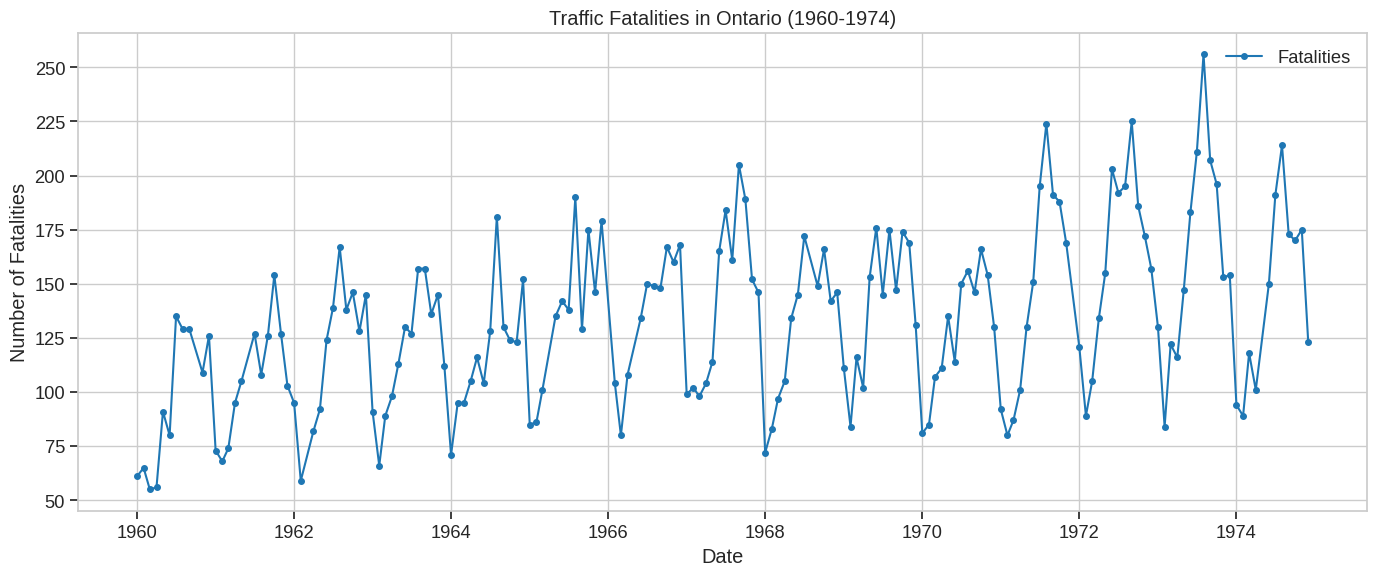

In [4]:
# Set date as the index
df.set_index('date', inplace=True)

# Initial time series visualization
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['deads'], marker='o', linestyle='-', markersize=4, label='Fatalities')
plt.title('Traffic Fatalities in Ontario (1960-1974)')
plt.xlabel('Date')
plt.ylabel('Number of Fatalities')
plt.legend()
plt.tight_layout()
plt.show()


At first glance, it seems that:
1. **Trend**: There is a slight upward trend. Accidents increase as the years progress, possibly linked to a greater number of cars on the roads between the 60s and 70s.
2. **Seasonality**: Regular peaks and valleys are noticeable, with a 12 month pattern. We can see that more accidents happen in summer, when people travel for holidays. We will verify this in more detail later.
3. **Variance**: The variance of the cycles also seems to be slightly increasing over time. This makes us think we might need to stabilize the variance (perhaps using a logarithmic transformation) before modeling.

### 1.1 Stationarity Evaluation

To statistically check the stationarity of the original series (although visually we know it is not, due to the trend and variance), we will apply the ADF test.

In [5]:
def test_stationarity(timeseries, title=""):
    print(f"--- ADF Test Results {title} ---")
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    print(dfoutput)
    
    if dftest[1] <= 0.05:
        print("\nConclusion: We reject the null hypothesis (H0). The series IS STATIONARY.")
    else:
        print("\nConclusion: We cannot reject the null hypothesis (H0). The series is NOT STATIONARY.")

test_stationarity(df['deads'], title="for Original Series")

--- ADF Test Results for Original Series ---
Test Statistic                  -2.157425
p-value                          0.222059
#Lags Used                      12.000000
Number of Observations Used    158.000000
Critical Value (1%)             -3.472431
Critical Value (5%)             -2.880013
Critical Value (10%)            -2.576619
dtype: float64

Conclusion: We cannot reject the null hypothesis (H0). The series is NOT STATIONARY.


## 2. Data Preprocessing

As we verified in the previous section, our time series has missing months. To be able to apply models like ARIMA or SARIMA, we need the series to be equally spaced in time without interruptions.

Therefore, the first step will be to **resample** the series to a monthly frequency (`MS`) and **fill in the missing values**. Given that the series has strong seasonality and that missing months are isolated, a simple linear interpolation would be enough.

Number of nulls before imputing: 9
Number of nulls after imputing: 0


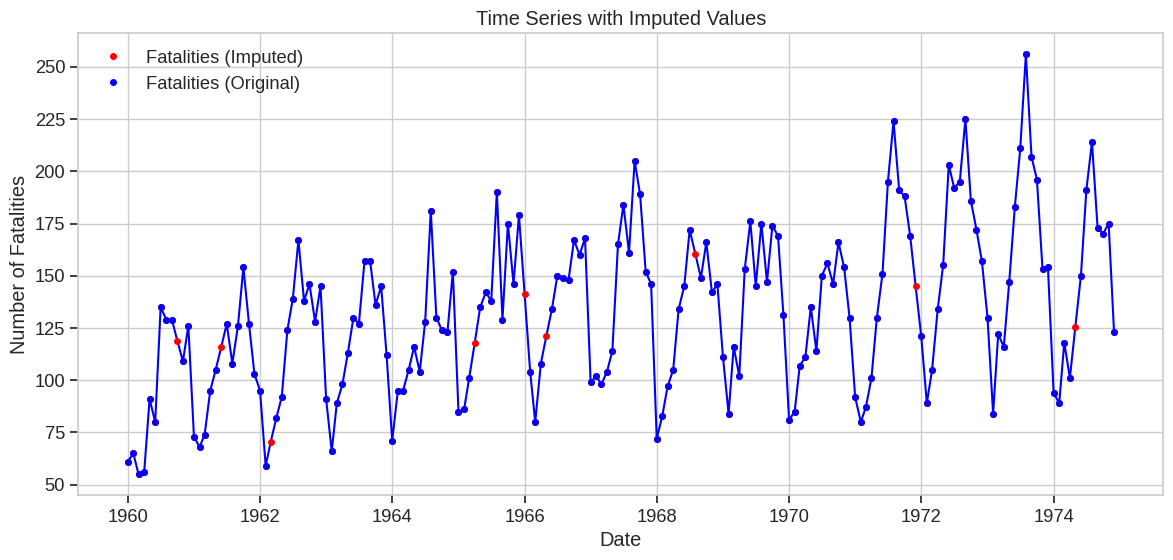

In [6]:
# Resample to a monthly frequency from start to end
df_resampled = df.resample('MS').asfreq()

print(f"Number of nulls before imputing: {df_resampled['deads'].isnull().sum()}")

# Imputation of missing values using time interpolation
df_resampled['deads'] = df_resampled['deads'].interpolate(method='linear')

print(f"Number of nulls after imputing: {df_resampled['deads'].isnull().sum()}")

# Visually verify the result of the imputation
plt.figure(figsize=(14, 6))
plt.plot(df_resampled.index, df_resampled['deads'], marker='', linestyle='-', color='blue')
plt.plot(df_resampled.index, df_resampled['deads'], marker='o', linestyle='', markersize=4, label='Fatalities (Imputed)', color='red')
plt.plot(df.index, df['deads'], marker='o', linestyle='', markersize=4, label='Fatalities (Original)', color='blue')
plt.title('Time Series with Imputed Values')
plt.xlabel('Date')
plt.ylabel('Number of Fatalities')
plt.legend()
plt.show()


After applied this preproccesing, the series is now continuous.
Additionally, we had detected that the variance increased slightly over time. Let's apply the **Box-Cox transformation** to stabilize the variance.

In [7]:
import numpy as np
import pandas as pd
from scipy import stats

# -------------------------------------------------------------------------
# Custom Implementation of Guerrero's Method (Guerrero, V. M. ,1993)
# Goal: Find lambda that minimizes the Coefficient of Variation of the 
#       standard deviation over rolling windows.
# -------------------------------------------------------------------------
def guerrero_lambda(series, min_lambda=-2, max_lambda=2, window_size=24):
    """
    Estimates the optimal Box-Cox lambda using the Guerrero method.
    """
    series_clean = series.copy()
    # Box-Cox requires strictly positive data
    if series_clean.min() <= 0:
        series_clean += np.abs(series_clean.min()) + 1
        
    # lambdas = np.round(np.arange(min_lambda, max_lambda, 0.1), 1) # Search range
    lambdas = np.arange(min_lambda, max_lambda, 0.1) # Search range
    cvs = [] # To store Coefficient of Variation
    
    for l in lambdas:
        # Apply transformation
        if l == 0:
            trans_data = np.log(series_clean)
        else:
            trans_data = (series_clean**l - 1) / l
        
        # Calculate rolling standard deviation
        s_trans = pd.Series(trans_data)
        roll_std = s_trans.rolling(window_size).std()
        
        # Calculate CV of the rolling std (Spread of the spread)
        valid_std = roll_std.dropna()
        cv = valid_std.std() / valid_std.mean()
        cvs.append(cv)
    
    # Return lambda that minimizes the variation of variance
    return np.round(lambdas[np.argmin(cvs)],1)

In [8]:
from scipy.stats import boxcox, boxcox_normmax

## Apply Box-Cox transformation - Guerrero
# find optimal lambda (as fecuency is monthly, we use a 2 years rolling window)
lambda_guerrero = guerrero_lambda(df_resampled['deads'], window_size=24) 
series_boxcox_guerrero = boxcox(df_resampled['deads'], lmbda=lambda_guerrero)
print(f"Optimal Box-Cox λ - Guerrero: {lambda_guerrero:.1f}")

## Apply Box-Cox transformation - MLE
# find optimal lambda (as fequency is monthly, we use a 2 years rolling window)
series_boxcox_mle, lambda_mle = boxcox(df_resampled['deads'])
print(f"Optimal Box-Cox λ - MLE: {lambda_mle:.1f}")

Optimal Box-Cox λ - Guerrero: -0.1
Optimal Box-Cox λ - MLE: 0.5


The primary goal of Guerrero method is to specifically stabilize variance. And as we are getting a lamba value close to 0, we will finally apply **logarithmic transformation** because it is simpler and more interpretable.

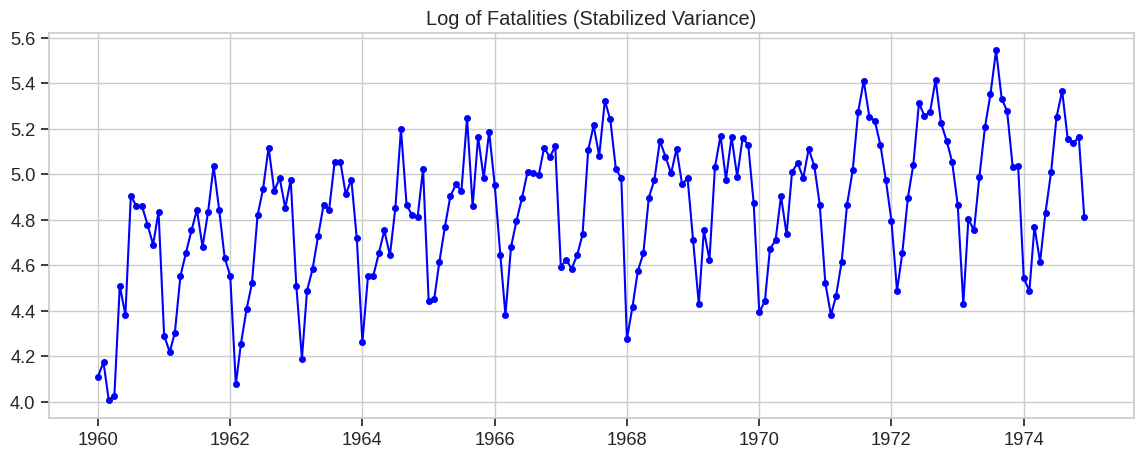

In [9]:
# Logarithmic transformation to stabilize variance
df_resampled['log_deads'] = np.log(df_resampled['deads'])

plt.figure(figsize=(14, 5))
plt.plot(df_resampled.index, df_resampled['log_deads'], marker='o', markersize=4, color='blue')
plt.title('Log of Fatalities (Stabilized Variance)')
plt.show()

Next, we will decompose the series to isolate and visually confirm the **Trend** and **Seasonality** components.

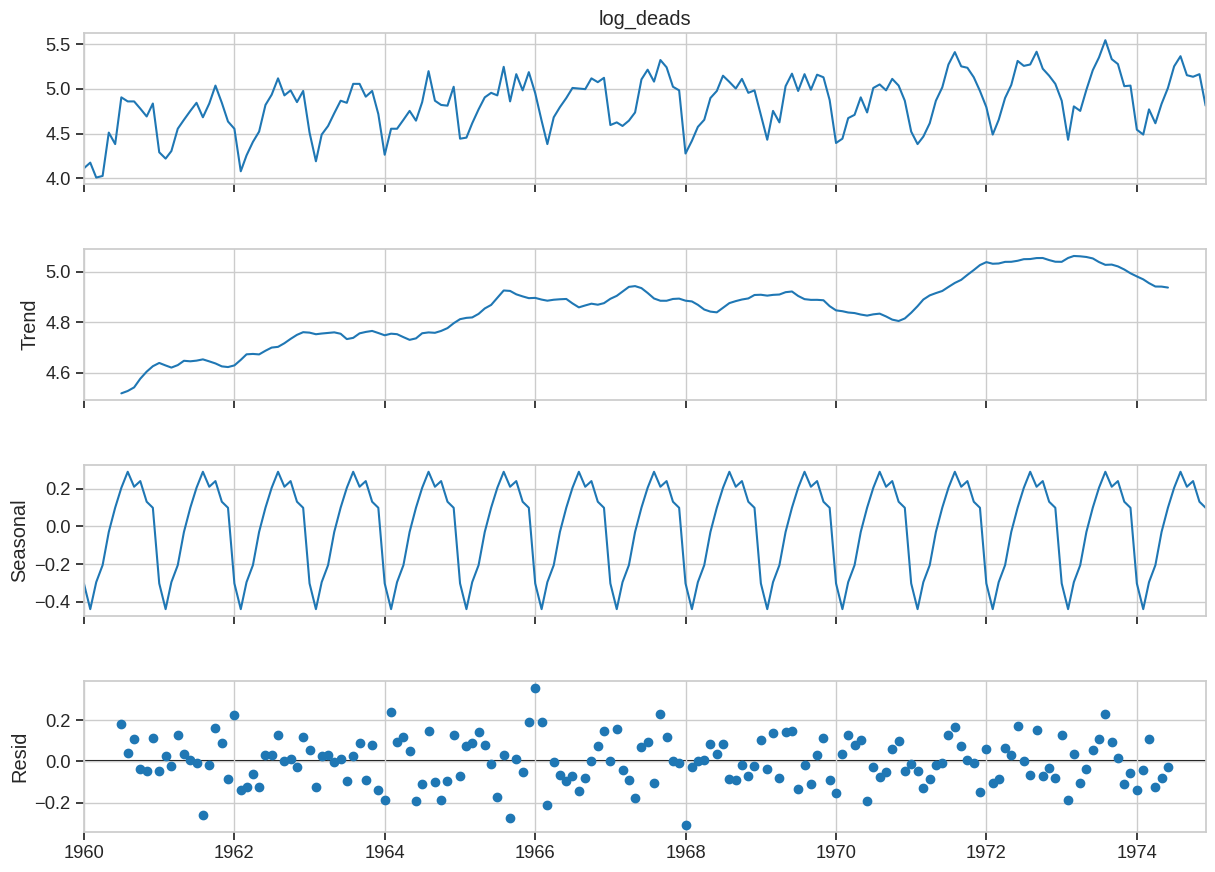

In [10]:
# Time series decomposition
decomposition = seasonal_decompose(df_resampled['log_deads'], model='additive')

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

The seasonal decomposition confirms our suspicions:
- There is a clear annual upward trend.
- There is a perfect cyclical seasonality (every 12 months).

This indicates that a **SARIMA** model will be the most suitable candidate, as it accounts for both the non-seasonal and strongly seasonal components.

In order to use SARIMA, we need to make the series stationary, so we will difference the series. First, a regular difference, and then a seasonal difference (m=12).

--- ADF Test Results for Differenced Series (d=1, D=1) ---
Test Statistic                  -4.278960
p-value                          0.000483
#Lags Used                      11.000000
Number of Observations Used    155.000000
Critical Value (1%)             -3.473259
Critical Value (5%)             -2.880374
Critical Value (10%)            -2.576812
dtype: float64

Conclusion: We reject the null hypothesis (H0). The series IS STATIONARY.


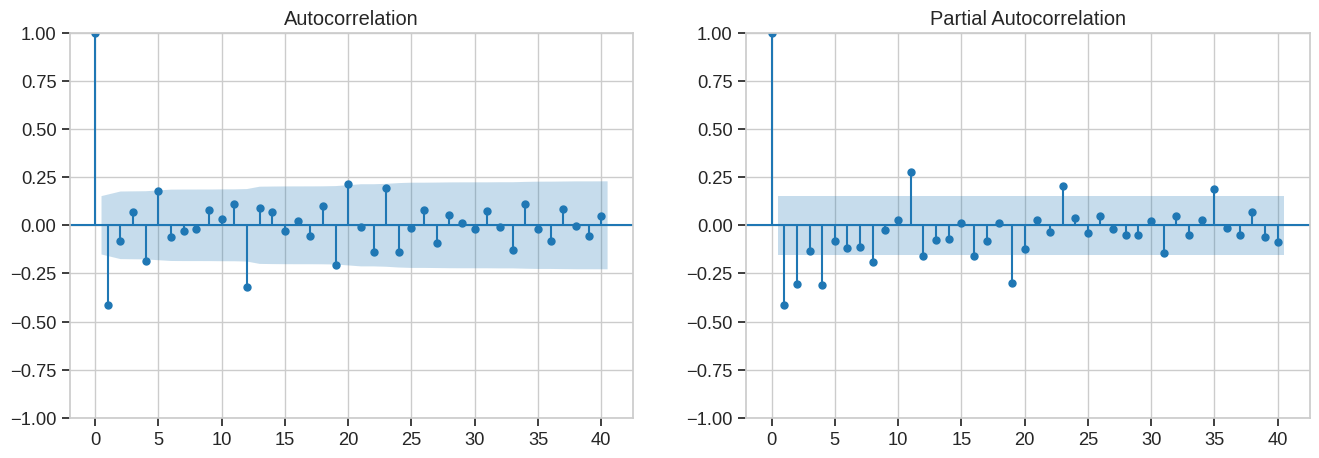

In [11]:
# Regular differencing for trend removal
df_resampled['log_deads_diff'] = df_resampled['log_deads'].diff()

# Seasonal differencing for seasonality removal
df_resampled['log_deads_diff_seasonal'] = df_resampled['log_deads_diff'].diff(12)

# We perform the ADF test again on the doubly differenced series
df_diff = df_resampled['log_deads_diff_seasonal'].dropna()
test_stationarity(df_diff, title="for Differenced Series (d=1, D=1)")

# Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_diff, ax=axes[0], lags=40)
plot_pacf(df_diff, ax=axes[1], lags=40)
plt.show()

## 3. Model Selection and Fitting

Now that we have the series ready, we proceed to split our data into Train and Test sets. If we look closely to the time series, we can observe how in 1971 there is a little change on the amplitude of the series. So, instead of using a 80/20 split (36 month for testing), we will only use the last 24 months for testing. This way we will keep almost two full seasons of the series (1971 and 1972) to model the change on the behaviour.

Train set size: 156
Test set size: 24


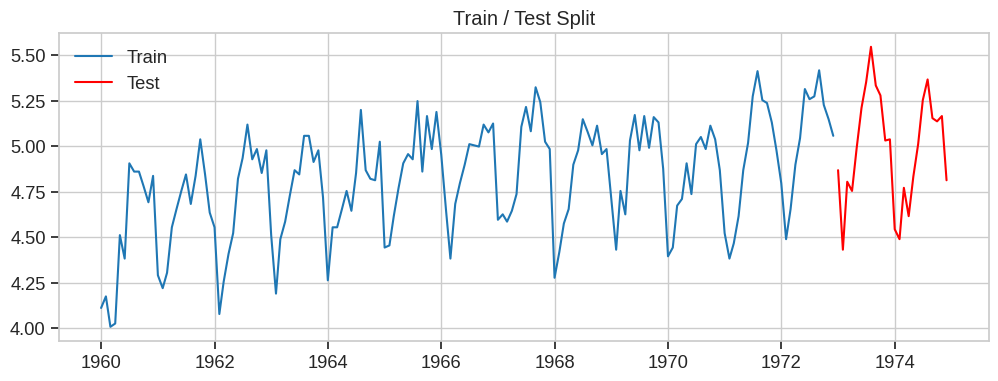

In [12]:
# Train-Test Split (last 24 months as Test)
train_size = len(df_resampled) - 24
train, test = df_resampled['log_deads'].iloc[:train_size], df_resampled['log_deads'].iloc[train_size:]

print(f"Train set size: {len(train)}")
print(f"Test set size: {len(test)}")

plt.figure(figsize=(12, 4))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='red')
plt.legend()
plt.title('Train / Test Split')
plt.show()

To find the best parameter fit `(p,d,q) x (P,D,Q,m)`, we could use the correlograms analyzed previously. However, we will use the `pmdarima` library (AutoARIMA) to perform an exhaustive search for the best model based on the Akaike Information Criterion (AIC). We will pass it the `log_deads` series and tell it to look for seasonality with m=12.

In [13]:
import pmdarima as pm

# Auto ARIMA to find the best SARIMA on the Log of the data
# We already know it will need D=1, d=1 since we achieved stationarity with them in previous analyses
auto_model = pm.auto_arima(train, 
                           start_p=0, start_q=0,
                           max_p=3, max_q=3, 
                           m=12,
                           start_P=0, start_Q=0,
                           max_P=2, max_Q=2,
                           seasonal=True,
                           d=1, D=1, 
                           trace=True,
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True,
                           random_state=SEED)

print("\n--- Best selected model summary ---")
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-24.009, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-65.528, Time=0.80 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=3.37 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=-45.628, Time=0.04 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=-76.913, Time=0.99 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=6.37 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=2.81 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=-50.492, Time=1.02 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=-91.580, Time=1.89 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=-78.395, Time=0.89 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=inf, Time=7.08 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=4.97 sec
 ARIMA(3,1,0)(2,1,0)[12]             : AIC=-90.489, Time=2.73 sec
 ARIMA(2,1,1)(2,1,0)[12]             : AIC=-108.315, Time=4.70 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=-98.121, 

AutoARIMA has found the model with the lowest AIC. Now let's analyze the residuals of the best model to validate it.

## 4. Model Validation and Predictive Performance

First, we will perform diagnostics on the residuals to ensure they resemble white noise (normal distribution, zero mean, and ACF without significant peaks).

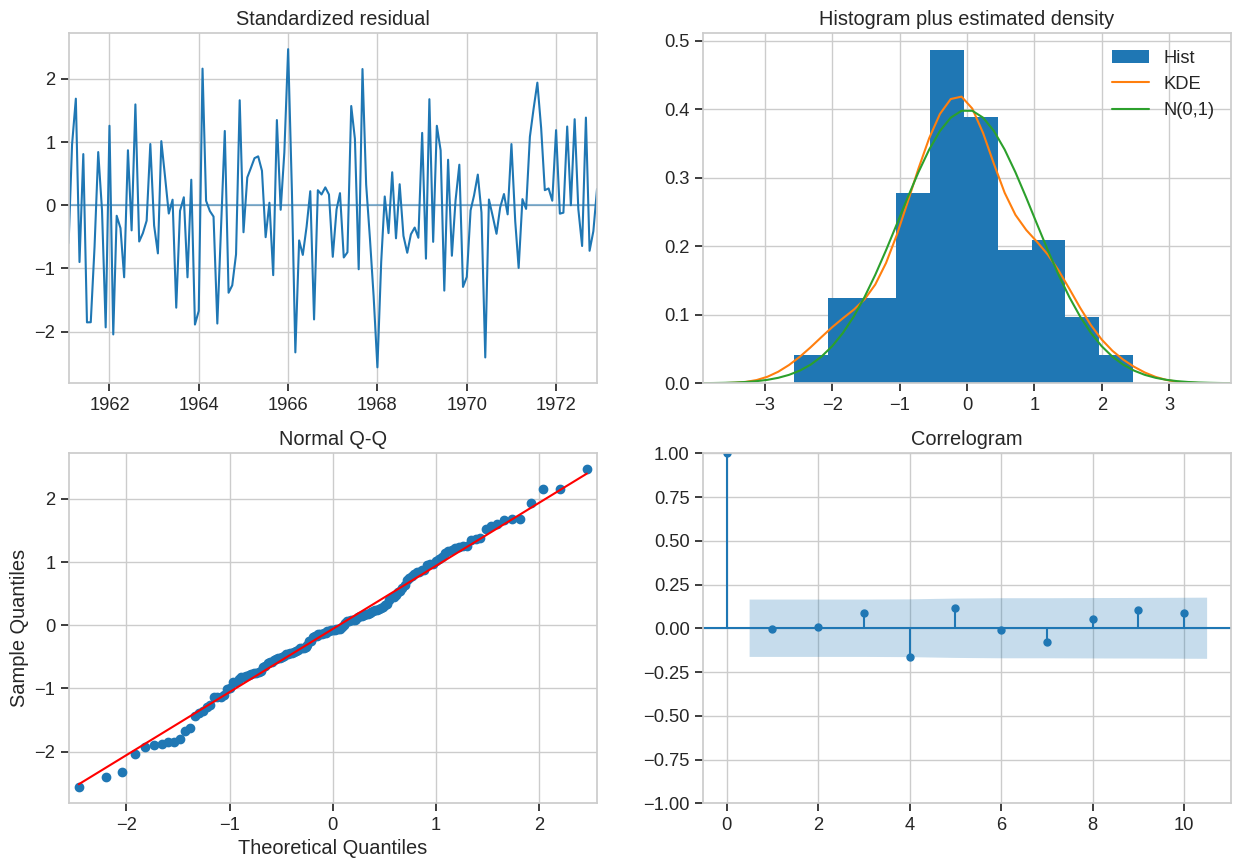

Ljung-Box test:
      lb_stat  lb_pvalue
24  36.360532   0.050619

Shapiro-Wilk test (p-value): 0.0000
Reject H0: residuals do not appear normally distributed.


In [14]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro

auto_model.plot_diagnostics(figsize=(15, 10))
plt.show()

residuals = auto_model.resid()

# Ljung-Box test: H0 = residuals are white noise (no autocorrelation)
lb_result = acorr_ljungbox(residuals, lags=[24], return_df=True)
print("Ljung-Box test:")
print(lb_result)

# Normality check: H0 = residuals are normally distributed
stat, p_val = shapiro(residuals)
print(f"\nShapiro-Wilk test (p-value): {p_val:.4f}")
if p_val > 0.05:
    print("Cannot reject H0: residuals appear normally distributed.")
else:
    print("Reject H0: residuals do not appear normally distributed.")

All diagnostic plots show that the residuals are normally distributed over time (they look like white noise). However, The Ljung-Box test (p=0.051) barely fails to reject the white noise hypothesis, and Shapiro-Wilk flags non-normality (p≈0.000). Let's plot a non-estandarized QQ-Plot to further analyze this matter.

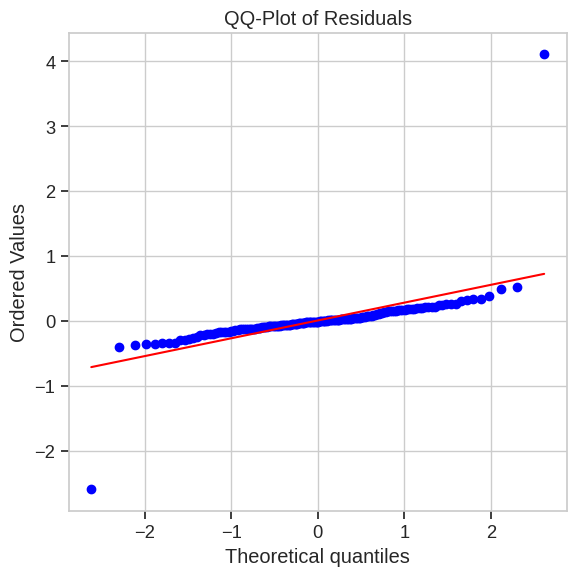

In [15]:
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("QQ-Plot of Residuals")
plt.tight_layout()
plt.show()

Looking at this QQ-plot we can see that residuals follow the normal line closely, with the exception of two outliers pulling at both tails. These are the culprits behind the Shapiro-Wilk rejection, not a structural problem with the model. So we can conclude it is valid.

Finally, we will project our predictions (Forecast) over the horizon of the Test set and compare numerical and visual metrics to evaluate its predictive performance.

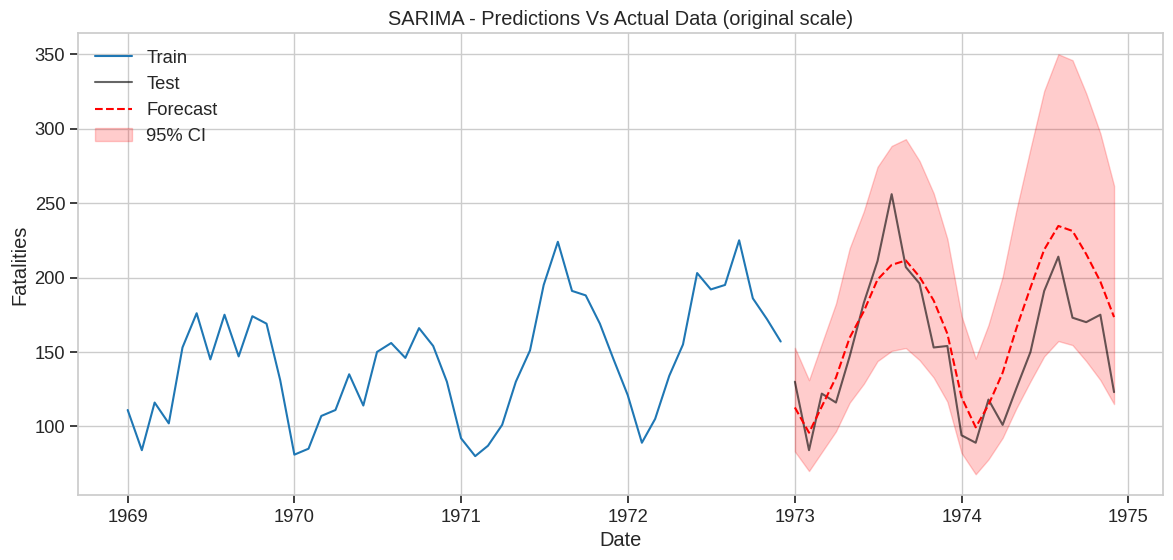

--- Predictive Performance Metrics ---
RMSE (Root Mean Squared Error): 28.66
MAE (Mean Absolute Error):      23.52
MAPE (Mean Absolute Pct Error): 16.31%


In [16]:
# Make predictions for the 24 periods (2 years) of the Test Set
forecast_log, conf_int = auto_model.predict(n_periods=len(test), return_conf_int=True, alpha=0.05)

# Reverse log transform
pred_real = np.exp(forecast_log)
conf_int_real = np.exp(conf_int)
test_real = np.exp(test)

plt.figure(figsize=(14, 6))
train_real = np.exp(train)
plt.plot(train_real.index[-48:], train_real[-48:], label='Train')
plt.plot(test_real.index, test_real, label='Test', color='black', alpha=0.6)
plt.plot(test_real.index, pred_real, label='Forecast', color='red', linestyle='--')

# Confidence interval
plt.fill_between(test_real.index, 
                 conf_int_real[:, 0], 
                 conf_int_real[:, 1], 
                 color='red', alpha=0.2, label='95% CI')

plt.title('SARIMA - Predictions Vs Actual Data (original scale)')
plt.xlabel('Date')
plt.ylabel('Fatalities')
plt.legend()
plt.show()

# Calculate performance metrics
rmse = np.sqrt(mean_squared_error(test_real, pred_real))
mae = mean_absolute_error(test_real, pred_real)
mape = mean_absolute_percentage_error(test_real, pred_real)

print(f"--- Predictive Performance Metrics ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAE (Mean Absolute Error):      {mae:.2f}")
print(f"MAPE (Mean Absolute Pct Error): {mape*100:.2f}%")

## 5. Conclusions

1. We have successfully preprocessed a dataset that contained monthly time gaps, interpolating the values continuously to preserve the statistical properties necessary for Time Series.
2. We identified in the EDA that we were dealing with a non-stationary series in mean (due to an increasing trend) and in variance (due to a scale effect). We managed to control this with a log transformation and by differencing the series (regular d=1 and seasonal D=1, m=12).
3. Using AutoARIMA, we selected the best SARIMA architecture: ARIMA(1,1,1)(2,1,0)[12]. The initial log transformation proved to be a wise decision, as it effectively stabilized the variance of the series.
4. Residual diagnostics showed that the model is statistically valid: the Ljung-Box test narrowly confirms the absence of autocorrelation, and while Shapiro-Wilk flags non-normality, the QQ-plot reveals this is driven by two isolated outliers rather than a structural issue. The model achieves a MAPE of 16.31% on the test set, capturing the seasonal pattern of summer peaks and winter drops in Ontario road fatalities.